# PD-LMC Implementation Class

In [1]:
import torch
import matplotlib.pyplot as plt

class PDLMC_2D:
    def __init__(self, f, g, h, eta=0.01):
        self.f = f
        self.g = g
        self.h = h

        self.eta = eta

        self.noise_scale = (2 * self.eta) ** 0.5

    def potential(self, x, lmbd, nu):
        g_x = self.g(x)
        h_x = self.h(x)

        lambda_term = lmbd * g_x
        nu_term = nu * h_x

        return self.f(x) + lambda_term + nu_term

    def _initialize_dual_variables(self, x):
        g_x = self.g(x)
        h_x = self.h(x)

        lmbd = torch.tensor(0.0)

        nu = torch.tensor(0.0)

        return lmbd, nu

    def _step(self, x, lmbd, nu):
        x = x.detach().requires_grad_(True)
        lmbd = lmbd.detach()
        nu = nu.detach()

        g_x = self.g(x)
        h_x = self.h(x)
        U = self.f(x) + lmbd * g_x + nu * h_x
        grad_U = torch.autograd.grad(U, x)[0]

        with torch.no_grad():
            noise = torch.randn_like(x)
            x_new = x - self.eta*grad_U + self.noise_scale * noise
            lmbd_new = torch.relu(lmbd + self.eta * g_x)
            nu_new = nu + self.eta * h_x

        return x_new, lmbd_new, nu_new

    def sample(self, iterations=10_000, initial_distribution=None, verbose=False):
        cloud = torch.empty((iterations, 2))

        if initial_distribution is None:
            x = torch.randn(2)
        else:
            x = initial_distribution()

        lmbd, nu = self._initialize_dual_variables(x)

        for i in range(iterations):
            if verbose and i%1000 == 0:
                print(f"Sample {i}/{iterations}")

            x, lmbd, nu = self._step(x, lmbd, nu)
            cloud[i] = x.detach().clone()

        return cloud

    def plot_samples(self, samples, considered_terms=2_000, xlim=(-2, 2), ylim=(-2, 2), constraint_points=None):
        samples = samples.detach().cpu()
        fig, ax = plt.subplots()
        ax.scatter(samples[-considered_terms:, 0], samples[-considered_terms:, 1], marker=".", s=10, alpha = 0.25)

        average = samples[-considered_terms:].mean(dim = 0)
        print(f"average of the distribution = {average}")

        ax.scatter(*average.tolist(), marker="x", color="orange",
               s=80, label="Sample Average")

        if constraint_points is not None:
            constraint_points = torch.as_tensor(constraint_points).detach().cpu()
    
            ax.plot(
                constraint_points[:, 0],
                constraint_points[:, 1],
                color="black",
                linewidth=1.5,
                label="Constraint"
            )

        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_aspect("equal")

        plt.show()

# Rejection Sample Implementation Class

In [2]:
import torch
import matplotlib.pyplot as plt


class RejectionSampler_2D:
    def __init__(self, proposal_distribution, constraint):
        self.proposal_distribution = proposal_distribution
        self.constraint = constraint

    def sample(self, iterations=30_000, size=100_000, verbose=False):
        inside = []
        n_inside = 0
        n_total = 0

        while n_inside < iterations:
            x = self.proposal_distribution(size)

            if x.ndim == 1:
                x = x.unsqueeze(0)

            mask = self.constraint(x)
            filtered = x[mask]

            remaining = iterations - n_inside
            if filtered.shape[0] > remaining:
                filtered = filtered[:remaining]

            inside.append(filtered)

            n_inside += filtered.shape[0]
            n_total += x.shape[0]

        samples = torch.cat(inside, dim=0)

        return samples

    def plot_samples(self, samples, xlim=(-2, 2), ylim=(-2, 2), constraint_points=None):
        samples = samples.detach().cpu()

        fig, ax = plt.subplots()

        ax.scatter(samples[:, 0], samples[:, 1], marker=".", s=10, alpha=0.25)

        average = samples.mean(dim = 0)
        print(f"average of the distribution = {average}")

        ax.scatter(*average.tolist(), marker="x", color="orange",
               s=80, label="Sample Average")

        if constraint_points is not None:
            constraint_points = torch.as_tensor(constraint_points).detach().cpu()
    
            ax.plot(
                constraint_points[:, 0],
                constraint_points[:, 1],
                color="black",
                linewidth=1.5,
                label="Constraint"
            )

        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_aspect("equal")
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        ax.set_title("Rejection sampling")

        plt.show()


## Auxiliary Functions for drawing the boundary regions

In [3]:
def ellipse_points(a, b, n=500):
    theta = torch.linspace(0, 2*torch.pi, n)

    x1 = a * torch.cos(theta)
    x2 = b * torch.sin(theta)

    return torch.stack((x1, x2), dim=1)

def square_points(a = 1.0):
    return torch.tensor([
        [-a, -a],
        [ a, -a],
        [ a,  a],
        [-a,  a],
        [-a, -a],
    ], dtype=torch.float32)

# Running the implementation for a circular region

Here we consider a circular region of radius 1.0

average of the distribution = tensor([0.3505, 0.3534])


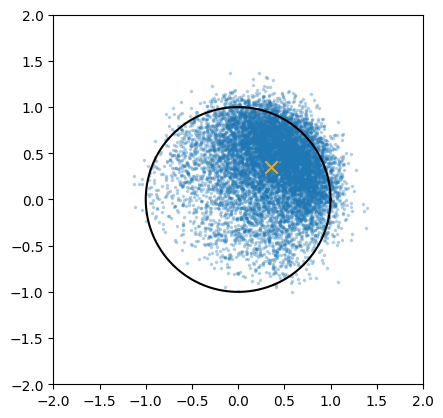

average of the distribution = tensor([0.3674, 0.3718])


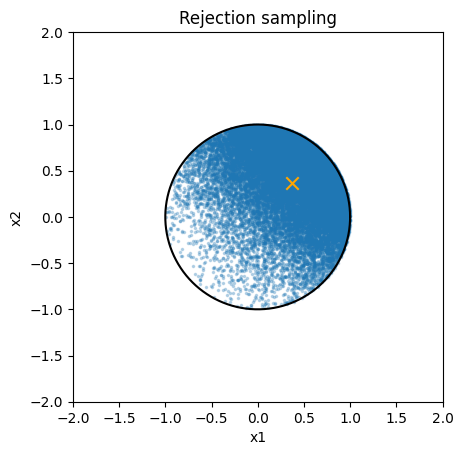

In [4]:
import torch

mean = torch.tensor([2.0, 2.0])

def f(x):
    return 0.5 * torch.sum((x - mean) ** 2)
def g(x):
    return torch.relu(torch.dot(x, x) - 1.0) - 0.001
def h(x):
    return torch.tensor(0.0)


constraint_circle = ellipse_points(1.0, 1.0)

sampler = PDLMC_2D(
    f=f,
    g=g,
    h=h,
    eta=0.01
)

samples = sampler.sample(
    iterations=30_000,
    initial_distribution=lambda: (
        torch.randn(2) + mean
    ),
    verbose=False,
)

sampler.plot_samples(
    samples,
    considered_terms=10_000,
    xlim=(-2, 2),
    ylim=(-2, 2),
    constraint_points=constraint_circle,
)


###########################
# Rejection Sampler #
##########################

sampler = RejectionSampler_2D(
    proposal_distribution=lambda n: torch.randn(n, 2) + mean,
    constraint=lambda x: torch.sum(x**2, dim=1) <= 1.0,
)

samples = sampler.sample(
    iterations=30_000,
    size=100_000,
)

sampler.plot_samples(
    samples,
    xlim=(-2, 2),
    ylim=(-2, 2),
    constraint_points=constraint_circle,
)

# Running the implementation for an elliptical region

Here we consider an elliptical region of axes 0.5 (x) and 2.0 (y)

average of the distribution = tensor([0.0484, 0.8772])


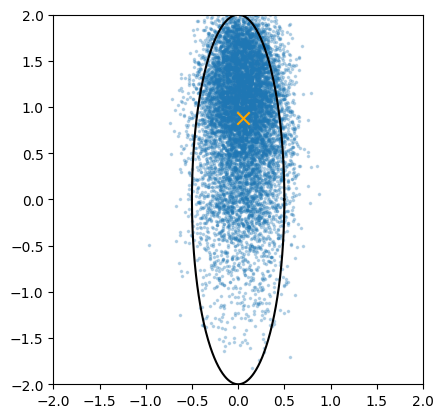

average of the distribution = tensor([0.1006, 1.0112])


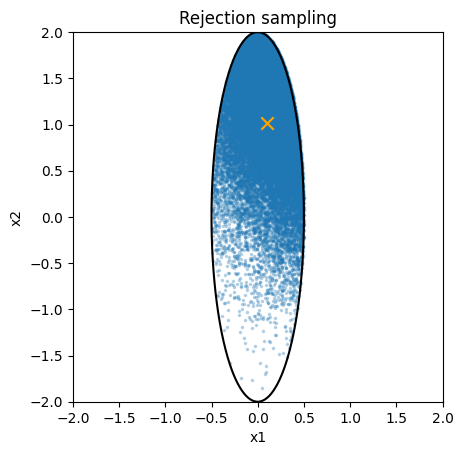

In [7]:
mean = torch.tensor([2.0, 2.0])

A = 0.5
B = 2.0

def g(x):
    return torch.relu((x[0]/A)**2 + (x[1]/B)**2 - 1.0) - 0.001

constraint_ellipse = ellipse_points(A, B)

sampler = PDLMC_2D(
    f=f,
    g=g,
    h=h,
    eta=0.01
)

samples = sampler.sample(
    iterations=30_000,
    initial_distribution=lambda: (
        torch.randn(2) + mean
    ),
    verbose=False,
)

sampler.plot_samples(
    samples,
    considered_terms=10_000,
    xlim=(-2, 2),
    ylim=(-2, 2),
    constraint_points=constraint_ellipse,
)


###########################
# Rejection Sampler       #
##########################

sampler = RejectionSampler_2D(
    proposal_distribution=lambda n: torch.randn(n, 2) + mean,
    constraint=lambda x: ((x[:, 0] / A)**2 + (x[:, 1] / B)**2 <= 1.0)
)

samples = sampler.sample(
    iterations=30_000,
    size=100_000,
)

sampler.plot_samples(
    samples,
    xlim=(-2, 2),
    ylim=(-2, 2),
    constraint_points=constraint_ellipse,
)

# Running the implementation for a square region

Here we consider a square region of radius 1.0

average of the distribution = tensor([0.5670, 0.5083])


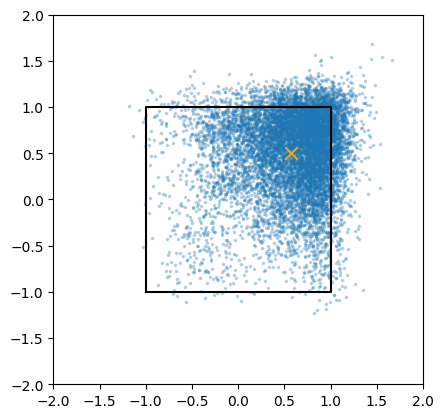

average of the distribution = tensor([0.4913, 0.4915])


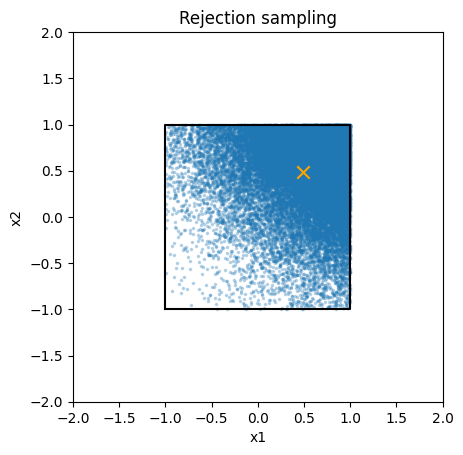

In [8]:
mean = torch.tensor([2.0, 2.0])

def g(x):
    return torch.relu(torch.max(torch.abs(x)) - 1.0) - 0.001

constraint_square = square_points()

sampler = PDLMC_2D(
    f=f,
    g=g,
    h=h,
    eta=0.01
)

samples = sampler.sample(
    iterations=30_000,
    initial_distribution=lambda: (
        torch.randn(2) + mean
    ),
    verbose=False,
)

sampler.plot_samples(
    samples,
    considered_terms=10_000,
    xlim=(-2, 2),
    ylim=(-2, 2),
    constraint_points=constraint_square,
)


###########################
# Rejection Sampler       #
##########################

sampler = RejectionSampler_2D(
    proposal_distribution=lambda n: torch.randn(n, 2) + mean,
    constraint=lambda x: ((torch.abs(x[:, 0]) <= 1.0) & (torch.abs(x[:, 1]) <= 1.0))
)

samples = sampler.sample(
    iterations=30_000,
    size=100_000,
)

sampler.plot_samples(
    samples,
    xlim=(-2, 2),
    ylim=(-2, 2),
    constraint_points=constraint_square,
)